In [1]:
import pandas as pd

In [2]:
dados = pd.read_excel('/content/drive/MyDrive/Análise Dados - Programaria/analise_dados_mod7_(1).xlsx')

In [3]:
dados.head()

,ID,IDADE,FAIXA IDADE,GENERO,COR/RACA/ETNIA,PCD,EXPERIENCIA_PROFISSIONAL_PREJUDICADA,ASPECTOS_PREJUDICADOS,VIVE_NO_BRASIL,ESTADO ONDE MORA,...,Você pretende mudar de emprego nos próximos 6 meses?,Quais os principais critérios que você leva em consideração no momento de decidir onde trabalhar?,Atualmente qual a sua forma de trabalho?,Qual a forma de trabalho ideal para você?,Caso sua empresa decida pelo modelo 100% presencial qual será sua atitude?,Sua empresa passu por Layoff em 2022?,Atuacao,Quais das linguagens listadas abaixo você utiliza no trabalho?,EM_BUSCA,ABERTO_OPORTUNIDADES
0,zzqzz3l9ily8nuo2m7wyzzqzz3w48o96,39.0,35-39,Masculino,Parda,Não,Não acredito que minha experiência profissiona...,NaN,True,Distrito Federal (DF),...,Não estou buscando e não pretendo mudar de emp...,Benefícios,Modelo 100% presencial,Modelo híbrido com dias fixos de trabalho pres...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Engenharia de Dados,SQL,0.0,0.0
1,zzls2oftfn9law393oezzls2ofhvfpzd,32.0,30-34,Masculino,Parda,Não,"Sim, acredito que a minha a experiência profis...",Aprovação em processos seletivos/entrevistas,True,Pará (PA),...,Estou em busca de oportunidades dentro ou fora...,"Remuneração/Salário, Plano de carreira e oport...",Modelo 100% presencial,Modelo híbrido flexível (o funcionário tem lib...,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Gestor,NaN,1.0,0.0
2,zzdwqzfqqp1ypc7ps6m0hzzdwqz292yi,53.0,50-54,Masculino,Branca,Não,NaN,NaN,True,Distrito Federal (DF),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido com dias fixos de trabalho pres...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,1,0.0,1.0
3,zzbqh3uy7yk7k9qmkzzbqtb4s9faqspl,27.0,25-29,Masculino,Branca,Não,NaN,NaN,True,Minas Gerais (MG),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Flexibilidade de trabalho...",Modelo híbrido flexível (o funcionário tem lib...,Modelo híbrido flexível (o funcionário tem lib...,Vou procurar outra oportunidade no modelo híbr...,Não ocorreram layoffs/demissões em massa na em...,desenvolve modelos preditivos e algoritmos de ...,0,0.0,1.0
4,zzaf1m95yan929rb94wzzaf1mekhvhpg,46.0,45-49,Feminino,Branca,Não,Não acredito que minha experiência profissiona...,NaN,True,Pará (PA),...,"Não estou buscando, mas me considero aberto a ...","Remuneração/Salário, Oportunidade de aprendiza...",Modelo 100% presencial,Modelo 100% presencial,Vou aceitar e retornar ao modelo 100% presencial,Não ocorreram layoffs/demissões em massa na em...,Outra atuação,SQL,0.0,1.0


# Vamos fazer um modelo para predizer o salário das pessoas na área de dados

### Alterações necessárias nas colunas individuais

In [4]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [5]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762
Empreendedor ou Empregado (CNPJ),410
"Desempregado, buscando recolocação",350
Estagiário,188
Servidor Público,156
Trabalho na área Acadêmica/Pesquisador,86
Somente Estudante (graduação),82
Vivo no Brasil e trabalho remoto para empresa de fora do Brasil,69
Vivo fora do Brasil e trabalho para empresa de fora do Brasil,46


In [6]:
dados =  dados[dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'] == 'Empregado (CLT)']

In [7]:
dados['QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?'].value_counts()

,count
QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?,
Empregado (CLT),2762


In [8]:
dados['COR/RACA/ETNIA'].value_counts()

,count
COR/RACA/ETNIA,
Branca,1805
Parda,661
Preta,181
Amarela,85
Prefiro não informar,16
Outra,10
Indígena,4


In [9]:
# Então vamos retirar esses com 16, 10 e 4 por que são números muito pequenos e podem acabar atrapalhando no resultado do nosso modelo
lista_retirar = ['Indígena', 'Prefiro não informar', 'Outra']

In [10]:
# função isin
# o ~ antes do filtro faz o cantrário do que esta apartir dele
dados = dados[~dados['COR/RACA/ETNIA'].isin(lista_retirar)]

In [11]:
# criando coluna COR_NAO_BRANCA
# se a coluna de COR/RACA/ETNIA for BRANCA essa nova coluna recebe 0 e caso contrario recebe 1
dados['NAO_BRANCA'] = dados['COR/RACA/ETNIA'].apply(lambda x: 1 if x!= 'Branca' else 0)

In [12]:
# tbm vamos utilizar o atributo de 'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'
dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].value_counts()

,count
QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?,
de 1 a 2 anos,743
de 3 a 4 anos,584
de 4 a 6 anos,416
Menos de 1 ano,353
Mais de 10 anos,277
de 7 a 10 anos,232
Não tenho experiência na área de dados,127


In [13]:
# usando regex para extrair o primeiro valor numerico de cada categoria, atravez da função extract
# atribundo o resultado a uma nova coluna
dados['TEMPO_EXPERIENCIA'] = dados['QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?'].str.extract(r'(\d+)')

In [14]:
dados['TEMPO_EXPERIENCIA'].value_counts()

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232


In [15]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
Acima de 3.000,1313
de 101 a 500,503
de 1.001 a 3.000,368
de 501 a 1.000,248
de 51 a 100,146
de 11 a 50,112
de 6 a 10,24
de 1 a 5,18


In [16]:
# removendo o '.' dos numeros da tabela NUMERO DE FUNCIONARIOS
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.replace('.','')

In [17]:
dados['NUMERO DE FUNCIONARIOS'] = dados['NUMERO DE FUNCIONARIOS'].str.extract(r'(\d+)')

In [18]:
dados['NUMERO DE FUNCIONARIOS'].value_counts()

,count
NUMERO DE FUNCIONARIOS,
3000,1313
101,503
1001,368
501,248
51,146
11,112
6,24
1,18


In [19]:
# verificando se tem numeros nulos
dados['NUMERO DE FUNCIONARIOS'].value_counts(dropna=False)

,count
NUMERO DE FUNCIONARIOS,
3000,1313
101,503
1001,368
501,248
51,146
11,112
6,24
1,18


In [20]:
# verificando se tem numeros nulos
# aparecenram 127 nulos que correspondem a opção 'Não tenho experiência na área de dados'
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
NaN,127


In [21]:
# preenchendo os campos nulos por 0
dados['TEMPO_EXPERIENCIA'] = dados['TEMPO_EXPERIENCIA'].fillna(0)

In [22]:
dados['TEMPO_EXPERIENCIA'].value_counts(dropna=False)

,count
TEMPO_EXPERIENCIA,
1,1096
3,584
4,416
10,277
7,232
0,127


In [23]:
dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].value_counts()

,count
Qual o principal motivo da sua insatisfação com a empresa atual?,
Gostaria de trabalhar em em outra área de atuação,69
Salário atual não corresponde ao mercado,53
Falta de oportunidade de crescimento no emprego atual,46
Falta de maturidade analítica na empresa,45
"Falta de oportunidade de crescimento no emprego atual, Salário atual não corresponde ao mercado, Falta de maturidade analítica na empresa",26
...,...
"O clima de trabalho/ambiente não é bom, Não tenho uma boa relação com meu líder/gestor, Gostaria de receber mais benefícios",1
Falta de organização nos processos internos,1
"Gostaria de receber mais benefícios, O clima de trabalho/ambiente não é bom, Falta de oportunidade de crescimento no emprego atual",1


In [24]:
# criando coluna INSATISFACAO
# se a coluna de 'Qual o principal motivo da sua insatisfação com a empresa atual?' tiver a palavra SALARIO  RECEBE O VALOR DE 1, caso contrário recebe 0
dados['INSATISFACAO'] = 0

In [25]:
# para pegar os dados da coluna utiliza-se o loc,
# depois faz o filtro dos dados não nulos
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

,Qual o principal motivo da sua insatisfação com a empresa atual?
1,0
2,0
7,1
10,0
26,1
...,...
4227,0
4234,1
4238,0
4240,1


In [26]:
# atribuindo o resultado a coluna INSATISFACAO
# é necessario filtrar os dados não nulos
dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'INSATISFACAO'] = dados.loc[dados['Qual o principal motivo da sua insatisfação com a empresa atual?'].notnull(), 'Qual o principal motivo da sua insatisfação com a empresa atual?'].apply(lambda x: 1 if 'Salário' in x else 0)

In [27]:
dados['INSATISFACAO'].value_counts()

,count
INSATISFACAO,
0,2453
1,279


In [28]:
# fazendo o mesmo procedimento na coluna 'NIVEL DE ENSINO'
dados['NIVEL DE ENSINO'].value_counts()

,count
NIVEL DE ENSINO,
Graduação/Bacharelado,1024
Pós-graduação,975
Mestrado,306
Estudante de Graduação,271
Doutorado ou Phd,100
Não tenho graduação formal,52
Prefiro não informar,4


In [29]:
dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x=='Não tenho graduação formal' else
                               1 if x== 'Estudante de Graduação' else
                               2 if x== 'Graduação/Bacharelado' else
                               3 if x== 'Pós-graduação' else
                               4 if x== 'Mestrado' else
                               5 if x== 'Doutorado ou Phd' else -1)

,NIVEL DE ENSINO
1,2
2,3
3,5
6,1
7,2
...,...
4262,3
4263,2
4266,2
4267,4


In [30]:
# atribuindo a mesma coluna
dados['NIVEL DE ENSINO'] = dados['NIVEL DE ENSINO'].apply(lambda x: 0 if x=='Não tenho graduação formal' else
                               1 if x== 'Estudante de Graduação' else
                               2 if x== 'Graduação/Bacharelado' else
                               3 if x== 'Pós-graduação' else
                               4 if x== 'Mestrado' else
                               5 if x== 'Doutorado ou Phd' else -1)

### Seleção das colunas que vai ser utilizada no modelo ( Atributos do Modelo)

In [31]:
dados.columns

Index(['ID', 'IDADE', 'FAIXA IDADE', 'GENERO', 'COR/RACA/ETNIA', 'PCD',
       'EXPERIENCIA_PROFISSIONAL_PREJUDICADA', 'ASPECTOS_PREJUDICADOS',
       'VIVE_NO_BRASIL', 'ESTADO ONDE MORA', 'UF ONDE MORA',
       'REGIAO ONDE MORA', 'MUDOU DE ESTADO?', 'REGIAO DE ORIGEM',
       'NIVEL DE ENSINO', 'ÁREA DE FORMAÇÃO',
       'QUAL SUA SITUAÇÃO ATUAL DE TRABALHO?', 'SETOR',
       'NUMERO DE FUNCIONARIOS', 'GESTOR?', 'CARGO COMO GESTOR', 'CARGO ATUAL',
       'FAIXA SALARIAL',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE DADOS VOCÊ TEM?',
       'QUANTO TEMPO DE EXPERIÊNCIA NA ÁREA DE TI/ENGENHARIA DE SOFTWARE VOCÊ TEVE ANTES DE COMEÇAR A TRABALHAR NA ÁREA DE DADOS?',
       'SALARIO', 'NOVO_NIVEL', 'NIVEL_Júnior', 'NIVEL_Pleno', 'NIVEL_Sênior',
       'GEARACAO', 'Quanto tempo de experiência na área de dados você tem?',
       'Quanto tempo de experiência na área de TI/Engenharia de Software você teve antes de começar a trabalhar na área de dados?',
       'Você está satisfeito na sua 

In [32]:
# colunas de atributos
dados[['IDADE','GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS','SALARIO', 'NOVO_NIVEL']]

,IDADE,GENERO,NAO_BRANCA,TEMPO_EXPERIENCIA,INSATISFACAO,SETOR,REGIAO ONDE MORA,NIVEL DE ENSINO,NUMERO DE FUNCIONARIOS,SALARIO,NOVO_NIVEL
1,32.0,Masculino,1,3,0,Outra Opção,Norte,2,3000,4695.0,Pessoa Gestora
2,53.0,Masculino,0,3,0,Finanças ou Bancos,Centro-oeste,3,3000,14202.0,Pleno
3,27.0,Masculino,0,4,0,Setor Automotivo,Sudeste,5,3000,15463.0,Sênior
6,21.0,Masculino,1,1,0,Finanças ou Bancos,Sudeste,1,3000,4491.0,Júnior
7,31.0,Feminino,0,1,1,Tecnologia/Fábrica de Software,Sul,2,6,2704.0,Júnior
...,...,...,...,...,...,...,...,...,...,...,...
4262,31.0,Masculino,1,3,0,Tecnologia/Fábrica de Software,Sudeste,3,501,18402.0,Pessoa Gestora
4263,26.0,Masculino,1,3,0,Tecnologia/Fábrica de Software,Sudeste,2,501,6641.0,Júnior
4266,26.0,Masculino,0,3,0,Tecnologia/Fábrica de Software,Sudeste,2,3000,4329.0,Pleno
4267,30.0,Feminino,0,1,0,Área de Consultoria,Sudeste,4,51,3758.0,Pleno


In [33]:
# atribuindo ao dados apenas as colunas de atributo
dados = dados[['IDADE','GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO', 'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS','SALARIO', 'NOVO_NIVEL']]

In [34]:
dados.columns

Index(['IDADE', 'GENERO', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'SETOR', 'REGIAO ONDE MORA', 'NIVEL DE ENSINO',
       'NUMERO DE FUNCIONARIOS', 'SALARIO', 'NOVO_NIVEL'],
      dtype='object')

In [35]:
# utilizando o get_dummies para variaves que não possuem ordenação de importancia
# drop_first vai cortar a primeira coluna
pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'REGIAO ONDE MORA', 'NOVO_NIVEL'], drop_first=True)

,IDADE,NAO_BRANCA,TEMPO_EXPERIENCIA,INSATISFACAO,NIVEL DE ENSINO,NUMERO DE FUNCIONARIOS,SALARIO,GENERO_Masculino,GENERO_Prefiro não informar,SETOR_Educação,...,SETOR_Varejo,SETOR_Área da Saúde,SETOR_Área de Consultoria,REGIAO ONDE MORA_Nordeste,REGIAO ONDE MORA_Norte,REGIAO ONDE MORA_Sudeste,REGIAO ONDE MORA_Sul,NOVO_NIVEL_Pessoa Gestora,NOVO_NIVEL_Pleno,NOVO_NIVEL_Sênior
1,32.0,1,3,0,2,3000,4695.0,True,False,False,...,False,False,False,False,True,False,False,True,False,False
2,53.0,0,3,0,3,3000,14202.0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
3,27.0,0,4,0,5,3000,15463.0,True,False,False,...,False,False,False,False,False,True,False,False,False,True
6,21.0,1,1,0,1,3000,4491.0,True,False,False,...,False,False,False,False,False,True,False,False,False,False
7,31.0,0,1,1,2,6,2704.0,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4262,31.0,1,3,0,3,501,18402.0,True,False,False,...,False,False,False,False,False,True,False,True,False,False
4263,26.0,1,3,0,2,501,6641.0,True,False,False,...,False,False,False,False,False,True,False,False,False,False
4266,26.0,0,3,0,2,3000,4329.0,True,False,False,...,False,False,False,False,False,True,False,False,True,False
4267,30.0,0,1,0,4,51,3758.0,False,False,False,...,False,False,True,False,False,True,False,False,True,False


In [36]:
dados = pd.get_dummies(dados, columns=['GENERO', 'SETOR', 'REGIAO ONDE MORA', 'NOVO_NIVEL'], drop_first=True)

### Separando conjunto de dados em 2

  1 - Conjunto de treinamento ( utilizado para aprender)
  
  2 - Conjunto de testes (avalia o desempenho do modelo para os dados que ele ainda não viu)

In [37]:
# separando os atributos dos objetivos
# drop usado pra excluir, axis indica a coluna
# x -- atributos / y -- alvo(target)
x = dados.drop('SALARIO', axis=1)
y = dados['SALARIO']

In [38]:
# Importando função
from sklearn.model_selection import train_test_split

In [39]:
# test_size -- 20% dos dados serão usados para o conjunto de testes (0.2), 80% para o conjunto de treinamento
# random_state -- semente para o gerador de numero aleatório, garante que a divisão dos dados seja reproduzivel
# resultado da função será dois conjuntos de atributos (um para teste e outro para treinamento), e dois conjuntos de alvo/target (um para teste e outro para treinamento)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [40]:
# Importando função que padroniza as caracteristicas, removendo a media e escalando para variança unitária ( normaliza os dados)
# algoritmos de Machine learning funcionam melhor quando os dados tem uma escala uniforme
from sklearn.preprocessing import StandardScaler

In [41]:
# criando objeto de normalização e aplica com o parametros os atributos
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

### Treinando o modelo

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
# criando objeto do modelo
model = LinearRegression()

In [44]:
# Parametros = atributo de treino ja normalizado e alvos( as respostas)
model.fit(x_train_scaled, y_train)

LinearRegression()

In [45]:
# predições
# parametro = atributo de teste ja normalizado
# resultado =  valores de salários que o modelo predizeu pra cada conjunto de atributos
model.predict(x_test_scaled)

array([21747.09955485, 16393.11133947,  3322.57047577,  4070.47453441,
       17456.19496593,  6983.80212226,  2895.99031002, 13153.66461021,
        2877.9092721 , 11369.42506472,  8810.37673337,  8889.0254039 ,
        8208.14893701, 18222.19249943, 18043.82669965,  8547.27229238,
       10852.30444684,  6617.36584584,  4625.9954692 , 13323.22681603,
        7195.39308176, 11065.52644244, 18377.46883881,  9352.55542353,
        9167.82728996, 22734.71129187,  9753.50647653, 11639.15276746,
       10102.19278383, 19826.59479755, 13074.70339455, 12732.60397625,
       18814.72054547,  5688.02809659,  5513.0550523 ,  3798.25066321,
       16433.57854552,  9712.53760549, 11600.32636999,  3345.07582467,
        7962.7143068 ,  8704.55524691,  5210.72145032,  6547.51938246,
       13349.11767882, 11420.03453199, 14284.61387643,  1406.89023734,
        5841.75882136, 23072.17785964,  8973.76843396, 10897.99012048,
       19191.98953638,  8864.87517892, 18019.58277215, 13090.32115152,
      

In [46]:
y_pred = model.predict(x_test_scaled)

### Avaliando desempenho do modelo treinado



Duas métricas comuns para avaliação de modelos de regressão são o erro quadrático médio e o coeficiente de determinação


*   O erro quadrático médio, o MSE,É uma métrica que calcula a média de diferença entre o valor predito e o valor real. Entretanto, nessa métrica, a diferença é elevada ao quadrado. Dessa maneira,penaliza valores que sejam muito diferentes entre o valor previsto e o valor real.
*   Já o R² é uma medida estatística de quão próximos os dados estão da linha de regressão, daquela reta que a gente já viu. A definição do R² é bastante simples, é a porcentagem da variação da variável resposta que é explicado por um modelo linear ou R² é igual a variação explicada dividido pela variação total. O R² está sempre entre 0% e 100%. O 0% indica que o modelo não explica nada da variabilidade dos dados de resposta ao redor da sua média e 100% indica que o modelo explica toda a variabilidade dos dados de resposta ao redor da sua média, ou seja, o foco é o 100%.


In [47]:
from sklearn.metrics import mean_squared_error, r2_score

In [48]:
# calculando o erro quadrático médio (MSE)
# calcula a diferença dos valores reais(y_test) e os valores predictos(y_pred)
mse = mean_squared_error(y_test, y_pred)
mse

23048733.9782972

*   O MSE do nosso modelo ficou com um valor absurdamente alto, ou seja,indicando que o modelo não está compredições precisas. Essa métrica é útil quando temos valores de target, alvo, mais incomuns, e que seria interessante que o nosso modelo não errasse. Por outro lado, como os erros são penalizados exponencialmente, os maiores têm um peso maior do que os erros menores. Então,se o nosso modelo faz apenas uma predição muito, mas muito ruim,o MSE irá elevar esse erro ao quadrado e, com isso,esse erro ficará ainda pior e acabaremos achando que o nosso modelo está performando pior do que ele realmente está. Outro ponto é que a escala do MSE não é a mesma do nosso target,do nosso salário, visto que os erros são elevados ao quadrado. Então,sua interpretação fica mais difícil.


*   Então, ao invés do MSE, a gente pode calcular uma outra métrica, que é a MAE, que é o erro absoluto, o erro médio absoluto, que calcula a média da diferença absoluta. Então, nesse caso, a gente não vai elevar ao quadrado,a gente vai pegar só a diferença entre o valor predito e o valor real, sem esse negócio de levar ao quadrado e tal. Nesse caso, os erros são penalizados linearmente, ouseja, todos terão o mesmo peso na média.A vantagem do MAE em relação ao MSE é que, como a escala é a mesma do target, do salário, do nosso alvo, é mais fácil de ser interpretado.



In [49]:
from sklearn.metrics import mean_absolute_error

In [50]:
mae = mean_absolute_error(y_test, y_pred)
mae

3298.964464206939

In [51]:
r2 = r2_score(y_test, y_pred)
r2

0.5297347873934933

Então, para saber se o nosso modelo está bom,precisamos analisar as métricas em conjunto. Temos um R2 de 0.52, um MAE de 3291 e um MSE de 23 milhões.Então temos uma variação razoável. Na média absoluta, os erros não são tão altos,pois 3 mil para as faixas salariais que temos é até aceitável, porém temos um MSE bem alto,o que significa que temos bastantes erros, que sim são altos. Para um modelo real de produção, nosso modelo não seria aceitável, mas vamos olhar um pouco melhor os resultados para entender se conseguimos usar ele para realizar algumas análises.

In [52]:
# platar um gráfico dos valores reais vs valores preditos
import matplotlib.pyplot as plt

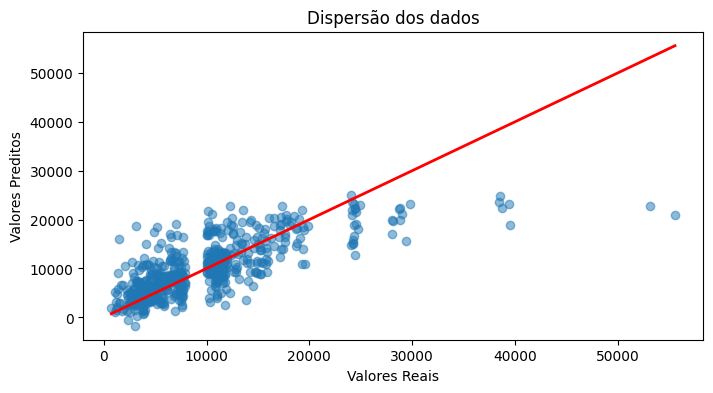

In [53]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Preditos')
plt.title('Dispersão dos dados')
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)], color='red', linewidth=2)
plt.show()

Bom, então nesse gráfico temos que a linha vermelha representa o nosso modelo de regressão linear, ou seja, os valores preditos. As bolinhas azuis são os valores reais dos salários. Podemos ver que abaixo de 10 mil reais aqui de salários,temos uma concentração de bolinhas,ou seja, muitos salários estão nessa faixa.

Analisando visualmente a performance do nosso modelo em relação aos valores reais, podemos ver que até aproximadamente 20 mil reais de salário,temos muitas bolinhas azuis, que são os valores reais, próximos dessa linha vermelha,que é a do modelo. Existem bolinhas acimada linha e abaixo,mas estão próximas da linha emsi, seguindo a mesma inclinação. Porém, acima de 20 mil reais,as bolinhas estão bem distantes da linha, correto? Elas seguem uma tendência mais achatada,ao invés de subir aqui, elas dão essa achatada,que não casa com a inclinação da regressão que criamos. Isso significa que ou podemos tentar no modelo com inclinação menor,ou realmente regressão linear não é um modelo adequado para o nosso problema.

Porém,como no nosso caso o objetivo real é fazer uma análise das relações com o salário, e na maioria dos casos conseguimos uma predição próxima,usaremos esse modelo assim mesmo. Nós podemos ver também quais atributos tiveram mais peso positivo ou negativo para o resultado do modelo. Em modelo de regressão,os coeficientes ou pesos eram aqueles multiplicadores que a gente viu na fórmula de regressão

In [54]:
nomes_atributos = x_train.columns
nomes_atributos

Index(['IDADE', 'NAO_BRANCA', 'TEMPO_EXPERIENCIA', 'INSATISFACAO',
       'NIVEL DE ENSINO', 'NUMERO DE FUNCIONARIOS', 'GENERO_Masculino',
       'GENERO_Prefiro não informar', 'SETOR_Educação',
       'SETOR_Entretenimento ou Esportes', 'SETOR_Filantropia/ONG's',
       'SETOR_Finanças ou Bancos', 'SETOR_Indústria',
       'SETOR_Internet/Ecommerce', 'SETOR_Marketing', 'SETOR_Outra Opção',
       'SETOR_Seguros ou Previdência', 'SETOR_Setor Alimentício',
       'SETOR_Setor Automotivo', 'SETOR_Setor Farmaceutico',
       'SETOR_Setor Imobiliário/ Construção Civil', 'SETOR_Setor Público',
       'SETOR_Setor de Energia', 'SETOR_Tecnologia/Fábrica de Software',
       'SETOR_Telecomunicação', 'SETOR_Varejo', 'SETOR_Área da Saúde',
       'SETOR_Área de Consultoria', 'REGIAO ONDE MORA_Nordeste',
       'REGIAO ONDE MORA_Norte', 'REGIAO ONDE MORA_Sudeste',
       'REGIAO ONDE MORA_Sul', 'NOVO_NIVEL_Pessoa Gestora', 'NOVO_NIVEL_Pleno',
       'NOVO_NIVEL_Sênior'],
      dtype='object')

In [55]:
# criando uma tabela (Data frame)
# model.coef_ -- coeficientes do modelo que a gente treinou
# criando a coluna 'coeficientes'
# index -- nome das linhas, no caso nossos atributos
pd.DataFrame(model.coef_, columns=['Coeficientes'], index=nomes_atributos )

,Coeficientes
IDADE,-133.027283
NAO_BRANCA,-423.401696
TEMPO_EXPERIENCIA,2004.015472
INSATISFACAO,-535.533311
NIVEL DE ENSINO,843.824926
NUMERO DE FUNCIONARIOS,797.206111
GENERO_Masculino,555.450771
GENERO_Prefiro não informar,92.976498
SETOR_Educação,-157.506247
SETOR_Entretenimento ou Esportes,231.353518


In [56]:
# armazenado a tabela em uma varoável
coefs = pd.DataFrame(model.coef_, columns=['Coeficientes'], index=nomes_atributos )

In [57]:
# ordenando a tabela
coefs.sort_values(by='Coeficientes', ascending=False)

,Coeficientes
NOVO_NIVEL_Pessoa Gestora,3965.837560
NOVO_NIVEL_Sênior,2008.062980
TEMPO_EXPERIENCIA,2004.015472
NOVO_NIVEL_Pleno,900.352033
NIVEL DE ENSINO,843.824926
NUMERO DE FUNCIONARIOS,797.206111
SETOR_Finanças ou Bancos,727.227138
SETOR_Internet/Ecommerce,693.103642
SETOR_Tecnologia/Fábrica de Software,637.817363
GENERO_Masculino,555.450771


In [58]:
coefs = coefs.sort_values(by='Coeficientes', ascending=False)

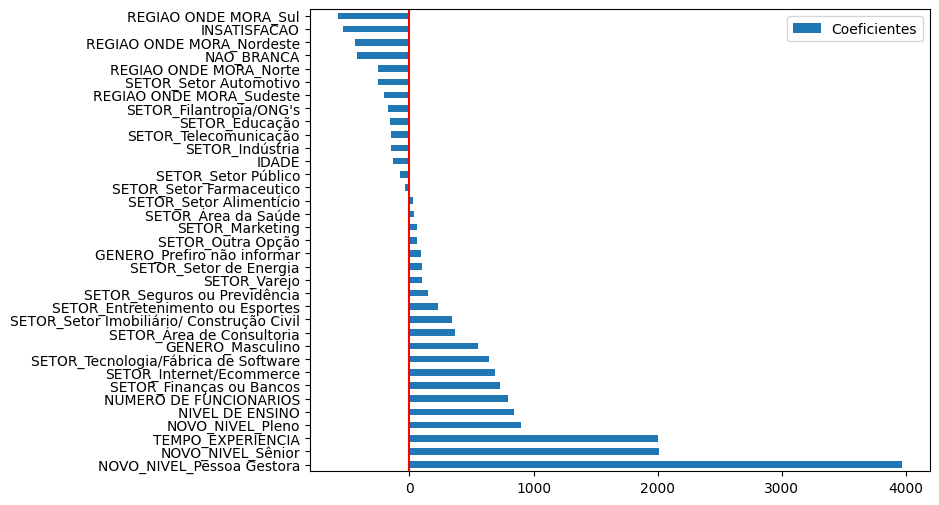

In [61]:
# criando um gráfico de barra horintal
coefs.plot.barh(figsize=(8,6))
plt.axvline(x=0, color='red')